# Demo Biosensor Workflow

This notebook demonstrates a replicate-aware calibration workflow for simulated electrochemical biosensor data.

## Workflow

The workflow includes:

1. Generate simulated replicate measurements
2. Summarize replicate signals by concentration
3. Fit a calibration curve
4. Estimate LOD and LOQ
5. Plot the calibration curve with error bars

In [8]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from examples.full_biosensor_workflow import generate_biosensor_replicates
from echem_signal_toolkit.calibration import (
    calibration_performance_summary,
    estimate_lod,
    estimate_loq,
    fit_replicate_calibration_curve,
    summarize_replicates,
)
from echem_signal_toolkit.plotting import plot_replicate_calibration_curve

## Generate Simulated Replicate Data

In [9]:
measurements = generate_biosensor_replicates()
measurements.head()

,sample_id,concentration,replicate,signal
0,0uM_rep1,0.0,1,1.501550e-07
1,0uM_rep2,0.0,2,1.876419e-07
2,0uM_rep3,0.0,3,1.154586e-07
3,1uM_rep1,1.0,1,2.499482e-07
4,1uM_rep2,1.0,2,3.087104e-07


## Summarize Replicates

In [10]:
replicate_summary = summarize_replicates(measurements)
replicate_summary

,concentration,signal_mean,signal_std,signal_count,signal_rsd_percent
0,0.0,1.510852e-07,3.610064e-08,3,23.894230
1,1.0,2.649949e-07,3.846654e-08,3,14.515955
2,5.0,1.301462e-06,1.597976e-07,3,12.278318
3,10.0,2.366139e-06,1.297517e-07,3,5.483688
4,20.0,4.464000e-06,1.700959e-07,3,3.810392
5,50.0,1.094124e-05,5.788215e-07,3,5.290275


## Fit Calibration Curve

In [11]:
fit_result = fit_replicate_calibration_curve(replicate_summary)
fit_result

{'n_points': 6,
 'slope': 2.1604144241811482e-07,
 'intercept': 1.5155876160555886e-07,
 'r_value': 0.9998892466847316,
 'r_squared': 0.99977850563576,
 'p_value': 1.8398765997905456e-08,
 'std_err': 1.6078166248948907e-09}

## Estimate LOD and LOQ

In [12]:
blank_signals = measurements.loc[
    measurements['concentration'] == 0.0,
    'signal',
]

lod = estimate_lod(blank_signals, slope=fit_result['slope'])
loq = estimate_loq(blank_signals, slope=fit_result['slope'])

performance = calibration_performance_summary(
    fit_result=fit_result,
    lod=lod,
    loq=loq,
    concentration_unit='uM',
    signal_unit='A',
)

pd.DataFrame([performance])

,sensitivity,sensitivity_unit,intercept,r_squared,lod,lod_unit,loq,loq_unit,n_points
0,2.160414e-07,A/uM,1.515588e-07,0.999779,0.501302,uM,1.671005,uM,6


## Plot Calibration Curve

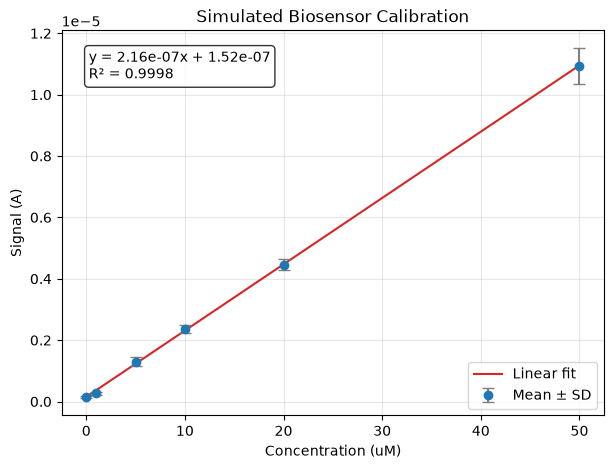

In [13]:
plot_replicate_calibration_curve(
    replicate_summary,
    fit_result,
    title='Simulated Biosensor Calibration',
    concentration_unit='uM',
    signal_unit='A',
);